<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 48px 40px 40px 40px; border-radius: 12px; margin-bottom: 8px;">
  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 16px;">
    <span style="background: #e94560; color: white; font-size: 11px; font-weight: 700; letter-spacing: 2px; padding: 4px 10px; border-radius: 4px; text-transform: uppercase;">dbt Analytics Engineering</span>
    <span style="color: #a0aec0; font-size: 12px; letter-spacing: 1px;">Medallion Architecture · Capstone Project</span>
  </div>
  <h1 style="color: #ffffff; font-size: 36px; font-weight: 800; margin: 0 0 10px 0; font-family: 'Segoe UI', sans-serif; letter-spacing: -0.5px;">☕ Jaffle Shop</h1>
  <h2 style="color: #e94560; font-size: 22px; font-weight: 400; margin: 0 0 20px 0; font-family: 'Segoe UI', sans-serif;">Business Performance Analysis</h2>
  <p style="color: #a0aec0; font-size: 14px; line-height: 1.6; max-width: 680px; margin: 0;">
    End-to-end analysis built on a <strong style="color: #e2e8f0;">Bronze → Silver → Gold</strong> dbt pipeline. 
    Raw seed data flows through staging views and ephemeral intermediates before landing 
    in materialised mart tables queried here via DuckDB.
  </p>
  <hr style="border: none; border-top: 1px solid #2d3748; margin: 24px 0 16px 0;">
  <div style="display: flex; gap: 32px;">
    <div><span style="color: #718096; font-size: 11px; text-transform: uppercase; letter-spacing: 1px;">Data Source</span><br><span style="color: #e2e8f0; font-size: 14px; font-weight: 600;">capstone_dev.duckdb</span></div>
    <div><span style="color: #718096; font-size: 11px; text-transform: uppercase; letter-spacing: 1px;">Analyses</span><br><span style="color: #e2e8f0; font-size: 14px; font-weight: 600;">Products · Stores · Customers</span></div>
    <div><span style="color: #718096; font-size: 11px; text-transform: uppercase; letter-spacing: 1px;">Pipeline</span><br><span style="color: #e2e8f0; font-size: 14px; font-weight: 600;">6 Staging + 4 Intermediate + 4 Mart</span></div>
  </div>
</div>

## 📋 Contents

| # | Section | Gold Layer Table | Key Metric |
|---|---------|-----------------|------------|
| 1 | [Setup & Connection](#setup) | — | Database handshake |
| 2 | [Product Profitability](#products) | `dim_products` | Net profit by menu item |
| 3 | [Store Performance](#stores) | `dim_stores` | Revenue vs profit + margin % |
| 4 | [Top Customer LTV](#customers) | `mart_most_valuable_customer` | Lifetime value ranking |

---
## ⚙️ 1 · Setup & Connection <a id="setup"></a>

Imports, shared style config, and a single DuckDB connection that all later cells reuse. Run this first.

In [3]:
import os
import warnings
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')

# ── Resolve DB path (works from project root or a subdirectory) ──────────────
db_path = 'capstone_dev.duckdb'
if not os.path.exists(db_path) and os.path.exists('../capstone_dev.duckdb'):
    db_path = '../capstone_dev.duckdb'

con = duckdb.connect(db_path)
print(f"✅  Connected → {os.path.abspath(db_path)}")

# ── Shared visual theme ──────────────────────────────────────────────────────
PALETTE = {
    'bg':        '#1a1a2e',
    'panel':     '#16213e',
    'accent':    '#e94560',
    'blue':      '#4a90e2',
    'green':     '#38b2ac',
    'gold':      '#f6c90e',
    'muted':     '#a0aec0',
    'text':      '#e2e8f0',
    'gridline':  '#2d3748',
}

def apply_dark_style(ax, title: str, xlabel: str = '', ylabel: str = ''):
    """Apply a consistent dark-panel style to any Axes object."""
    ax.set_facecolor(PALETTE['panel'])
    ax.figure.patch.set_facecolor(PALETTE['bg'])
    ax.set_title(title, color=PALETTE['text'], fontsize=15, fontweight='bold',
                 pad=18, loc='left')
    ax.set_xlabel(xlabel, color=PALETTE['muted'], fontsize=11, labelpad=10)
    ax.set_ylabel(ylabel, color=PALETTE['muted'], fontsize=11, labelpad=10)
    ax.tick_params(colors=PALETTE['muted'], labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor(PALETTE['gridline'])
    ax.grid(axis='y', color=PALETTE['gridline'], linestyle='--', linewidth=0.6, alpha=0.8)
    ax.set_axisbelow(True)
    return ax

def fmt_dollar(val: float) -> str:
    return f'${val:,.0f}' if val >= 1 else f'${val:.2f}'

print("🎨  Style helpers loaded.")

✅  Connected → /home/krish/capstone-project/capstone_dev.duckdb
🎨  Style helpers loaded.


---
## 📦 2 · Product Profitability <a id="products"></a>

> **Gold table:** `main.dim_products`  
> **dbt lineage:** `stg_products` → `int_product_sales_aggregated` → **`dim_products`**

Which menu items generate the most absolute net profit? The bar heights encode total profit; the red accent line overlays **volume sold** on a secondary axis so you can spot high-margin-but-low-volume items at a glance.

KeyError: 'total_volume_sold'

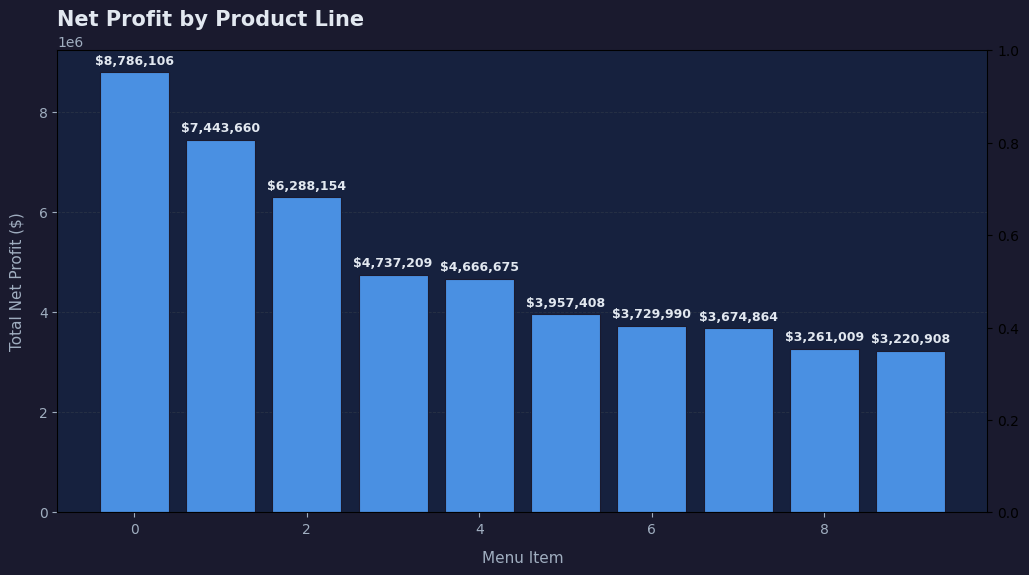

In [ ]:
df_products = con.execute("""
    SELECT
        product_name,
        total_sold,
        gross_revenue,
        total_profit
    FROM main.dim_products
    WHERE total_sold > 0
    ORDER BY total_profit DESC
""").df()

# ── Chart ────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 6))
apply_dark_style(ax1,
    title='Net Profit by Product Line',
    xlabel='Menu Item',
    ylabel='Total Net Profit ($)')

x = range(len(df_products))
bars = ax1.bar(x, df_products['total_profit'],
               color=PALETTE['blue'], edgecolor=PALETTE['bg'],
               linewidth=0.8, zorder=3)

# Value labels above bars
for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, h + max(df_products['total_profit']) * 0.012,
             fmt_dollar(h), ha='center', va='bottom',
             color=PALETTE['text'], fontsize=9, fontweight='bold')

# Secondary axis: volume sold
ax2 = ax1.twinx()
ax2.set_facecolor(PALETTE['panel'])
ax2.plot(x, df_products['total_sold'],
         color=PALETTE['accent'], marker='o', linewidth=2,
         markersize=7, zorder=4, label='Units Sold')
ax2.set_ylabel('Units Sold', color=PALETTE['accent'], fontsize=11, labelpad=10)
ax2.tick_params(axis='y', colors=PALETTE['accent'], labelsize=10)
for spine in ax2.spines.values():
    spine.set_edgecolor(PALETTE['gridline'])

ax1.set_xticks(list(x))
ax1.set_xticklabels(df_products['product_name'], rotation=25, ha='right')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: fmt_dollar(v)))

# Legend
profit_patch = mpatches.Patch(color=PALETTE['blue'], label='Net Profit')
ax1.legend(handles=[profit_patch], loc='upper right',
           facecolor=PALETTE['bg'], edgecolor=PALETTE['gridline'],
           labelcolor=PALETTE['text'], fontsize=10)
ax2.legend(loc='upper center',
           facecolor=PALETTE['bg'], edgecolor=PALETTE['gridline'],
           labelcolor=PALETTE['text'], fontsize=10)

fig.tight_layout()
plt.savefig('product_profitability.png', dpi=150, bbox_inches='tight',
            facecolor=PALETTE['bg'])
plt.show()

# ── Summary table ────────────────────────────────────────────────────────────
print("\n── Product Summary ──────────────────────────────────────")
summary = df_products.copy()
summary['gross_revenue'] = summary['gross_revenue'].map('${:,.2f}'.format)
summary['total_profit']  = summary['total_profit'].map('${:,.2f}'.format)
print(summary.to_string(index=False))

---
## 🏪 3 · Store Performance <a id="stores"></a>

> **Gold table:** `main.dim_stores`  
> **dbt lineage:** `stg_stores` + `int_order_items_joined` + `int_store_costs_aggregated` → **`dim_stores`**

Side-by-side grouped bars compare **gross revenue vs net profit** per location. The profit margin % badge floats above each profit bar so the operational efficiency of each store is readable at a glance.

In [ ]:
df_stores = con.execute("""
    SELECT
        store_name,
        total_revenue,
        total_profit,
        profit_margin_pct
    FROM main.dim_stores
    ORDER BY total_revenue DESC
""").df()

# ── Chart ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
apply_dark_style(ax,
    title='Store Performance: Revenue vs Net Profit',
    xlabel='Location',
    ylabel='Financials ($)')

n      = len(df_stores)
x      = range(n)
width  = 0.38
offset = width / 2 + 0.02

rev_bars = ax.bar([i - offset for i in x], df_stores['total_revenue'],
                  width, label='Gross Revenue',
                  color=PALETTE['blue'], edgecolor=PALETTE['bg'],
                  linewidth=0.8, zorder=3)

prof_bars = ax.bar([i + offset for i in x], df_stores['total_profit'],
                   width, label='Net Profit',
                   color=PALETTE['green'], edgecolor=PALETTE['bg'],
                   linewidth=0.8, zorder=3)

# Margin badges above profit bars
for i, bar in enumerate(prof_bars):
    h      = bar.get_height()
    margin = df_stores['profit_margin_pct'].iloc[i]
    ax.annotate(
        f'{margin}%',
        xy=(bar.get_x() + bar.get_width() / 2, h),
        xytext=(0, 10), textcoords='offset points',
        ha='center', va='bottom',
        color=PALETTE['gold'], fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.25', fc=PALETTE['bg'],
                  ec=PALETTE['gold'], lw=1, alpha=0.85)
    )

ax.set_xticks(list(x))
ax.set_xticklabels(df_stores['store_name'], rotation=15, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: fmt_dollar(v)))
ax.legend(facecolor=PALETTE['bg'], edgecolor=PALETTE['gridline'],
          labelcolor=PALETTE['text'], fontsize=10)

fig.tight_layout()
plt.savefig('store_performance.png', dpi=150, bbox_inches='tight',
            facecolor=PALETTE['bg'])
plt.show()

# ── Summary table ────────────────────────────────────────────────────────────
print("\n── Store Summary ─────────────────────────────────────────")
summary = df_stores.copy()
summary['total_revenue'] = summary['total_revenue'].map('${:,.2f}'.format)
summary['total_profit']  = summary['total_profit'].map('${:,.2f}'.format)
summary['profit_margin_pct'] = summary['profit_margin_pct'].map('{:.1f}%'.format)
print(summary.to_string(index=False))

---
## 👑 4 · Top Customer Lifetime Value <a id="customers"></a>

> **Gold table:** `main.mart_most_valuable_customer`  
> **dbt lineage:** `stg_customers` + `int_customer_order_history` → **`mart_most_valuable_customer`**

A ranked horizontal bar chart of the **top 10 customers by cumulative lifetime spend**. The accent stripe encodes average purchase size — a wide stripe relative to the full LTV bar signals a high-ticket, low-frequency buyer.

In [ ]:
df_customers = con.execute("""
    SELECT
        (first_name || ' ' || last_name) AS customer_full_name,
        lifetime_value,
        avg_purchase
    FROM main.mart_most_valuable_customer
    WHERE lifetime_value > 0
    ORDER BY lifetime_value DESC
    LIMIT 10
""").df()

# ── Chart ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_facecolor(PALETTE['panel'])
fig.patch.set_facecolor(PALETTE['bg'])

y_pos = range(len(df_customers))

# Full LTV bars
ax.barh(y_pos, df_customers['lifetime_value'],
        color=PALETTE['blue'], edgecolor=PALETTE['bg'],
        height=0.65, linewidth=0.8, zorder=3, label='Lifetime Value')

# Avg purchase overlay (accent stripe at left edge of each bar)
ax.barh(y_pos, df_customers['avg_purchase'],
        color=PALETTE['accent'], edgecolor=PALETTE['bg'],
        height=0.65, linewidth=0.8, zorder=4, alpha=0.85,
        label='Avg Purchase')

# LTV dollar labels
x_max = df_customers['lifetime_value'].max()
for i, (ltv, avg) in enumerate(
        zip(df_customers['lifetime_value'], df_customers['avg_purchase'])):
    ax.text(ltv + x_max * 0.008, i, fmt_dollar(ltv),
            va='center', color=PALETTE['text'],
            fontsize=10, fontweight='bold')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(df_customers['customer_full_name'],
                   color=PALETTE['text'], fontsize=10)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: fmt_dollar(v)))

apply_dark_style(ax,
    title='Top 10 Customers — Lifetime Value',
    xlabel='Cumulative Spend ($)',
    ylabel='')
ax.grid(axis='x', color=PALETTE['gridline'], linestyle='--',
        linewidth=0.6, alpha=0.8)
ax.grid(axis='y', visible=False)

ax.legend(facecolor=PALETTE['bg'], edgecolor=PALETTE['gridline'],
          labelcolor=PALETTE['text'], fontsize=10)

fig.tight_layout()
plt.savefig('customer_ltv.png', dpi=150, bbox_inches='tight',
            facecolor=PALETTE['bg'])
plt.show()

# ── Summary table ────────────────────────────────────────────────────────────
print("\n── Top 10 Customer Summary ───────────────────────────────")
summary = df_customers.copy()
summary['lifetime_value'] = summary['lifetime_value'].map('${:,.2f}'.format)
summary['avg_purchase']   = summary['avg_purchase'].map('${:,.2f}'.format)
print(summary.to_string(index=False))

---
## 🏁 5 · Wrap-up

Close the DuckDB connection and confirm all three PNG exports were written.

In [ ]:
con.close()

exports = [
    'product_profitability.png',
    'store_performance.png',
    'customer_ltv.png',
]
print("── Export check ──────────────────────────────────────────")
for f in exports:
    status = '✅' if os.path.exists(f) else '❌  MISSING'
    print(f"  {status}  {f}")

print("\n🎉  Analysis complete. Connection safely closed.")